In [3]:
!pip install scikit-learn matplotlib seaborn sentence-transformers


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.3 MB 17.5 MB/s eta 0:00:01
   --------------------------------- ------ 7.1/8.3 MB 17.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 15.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 21.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----------------- ---------------------- 3.1/7.2 MB 17.4 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 18.0 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 17.3 MB/s  0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- -------------------

Caricamento del modello: all-mpnet-base-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10468.40it/s]



TOPIC (Short)        | CyBOK Dist | ECSF Dist  | DELTA (CyBOK Advantage)
Principles & Arch.   | 0.4081     | 0.4948     | +0.0867 ✅
Func. Requirements   | 0.6411     | 0.5399     | -0.1012 
Wireless Security    | 0.0495     | 0.7203     | +0.6708 ✅
IPsec Protocol       | 0.4033     | 0.5827     | +0.1794 ✅
SSL / TLS            | 0.3105     | 0.7810     | +0.4705 ✅
TLS (Transport)      | 0.2129     | 0.6640     | +0.4511 ✅
Email Security       | 0.7163     | 0.7353     | +0.0190 ✅
HTTPS                | 0.0000     | 0.7828     | +0.7828 ✅
WebRTC Security      | 0.2846     | 0.5813     | +0.2967 ✅
Cloud Security       | 0.1894     | 0.5664     | +0.3770 ✅
Malware Taxonomy     | 0.3933     | 0.5167     | +0.1235 ✅
APT Taxonomy         | 0.6047     | 0.2043     | -0.4004 
Malware Counterm.    | 0.4480     | 0.7596     | +0.3116 ✅
DoS / DDoS           | 0.1153     | 0.6563     | +0.5410 ✅
IDS Techniques       | 0.3008     | 0.5425     | +0.2417 ✅
Firewalls & IPS      | 0.1053     | 0.4849 

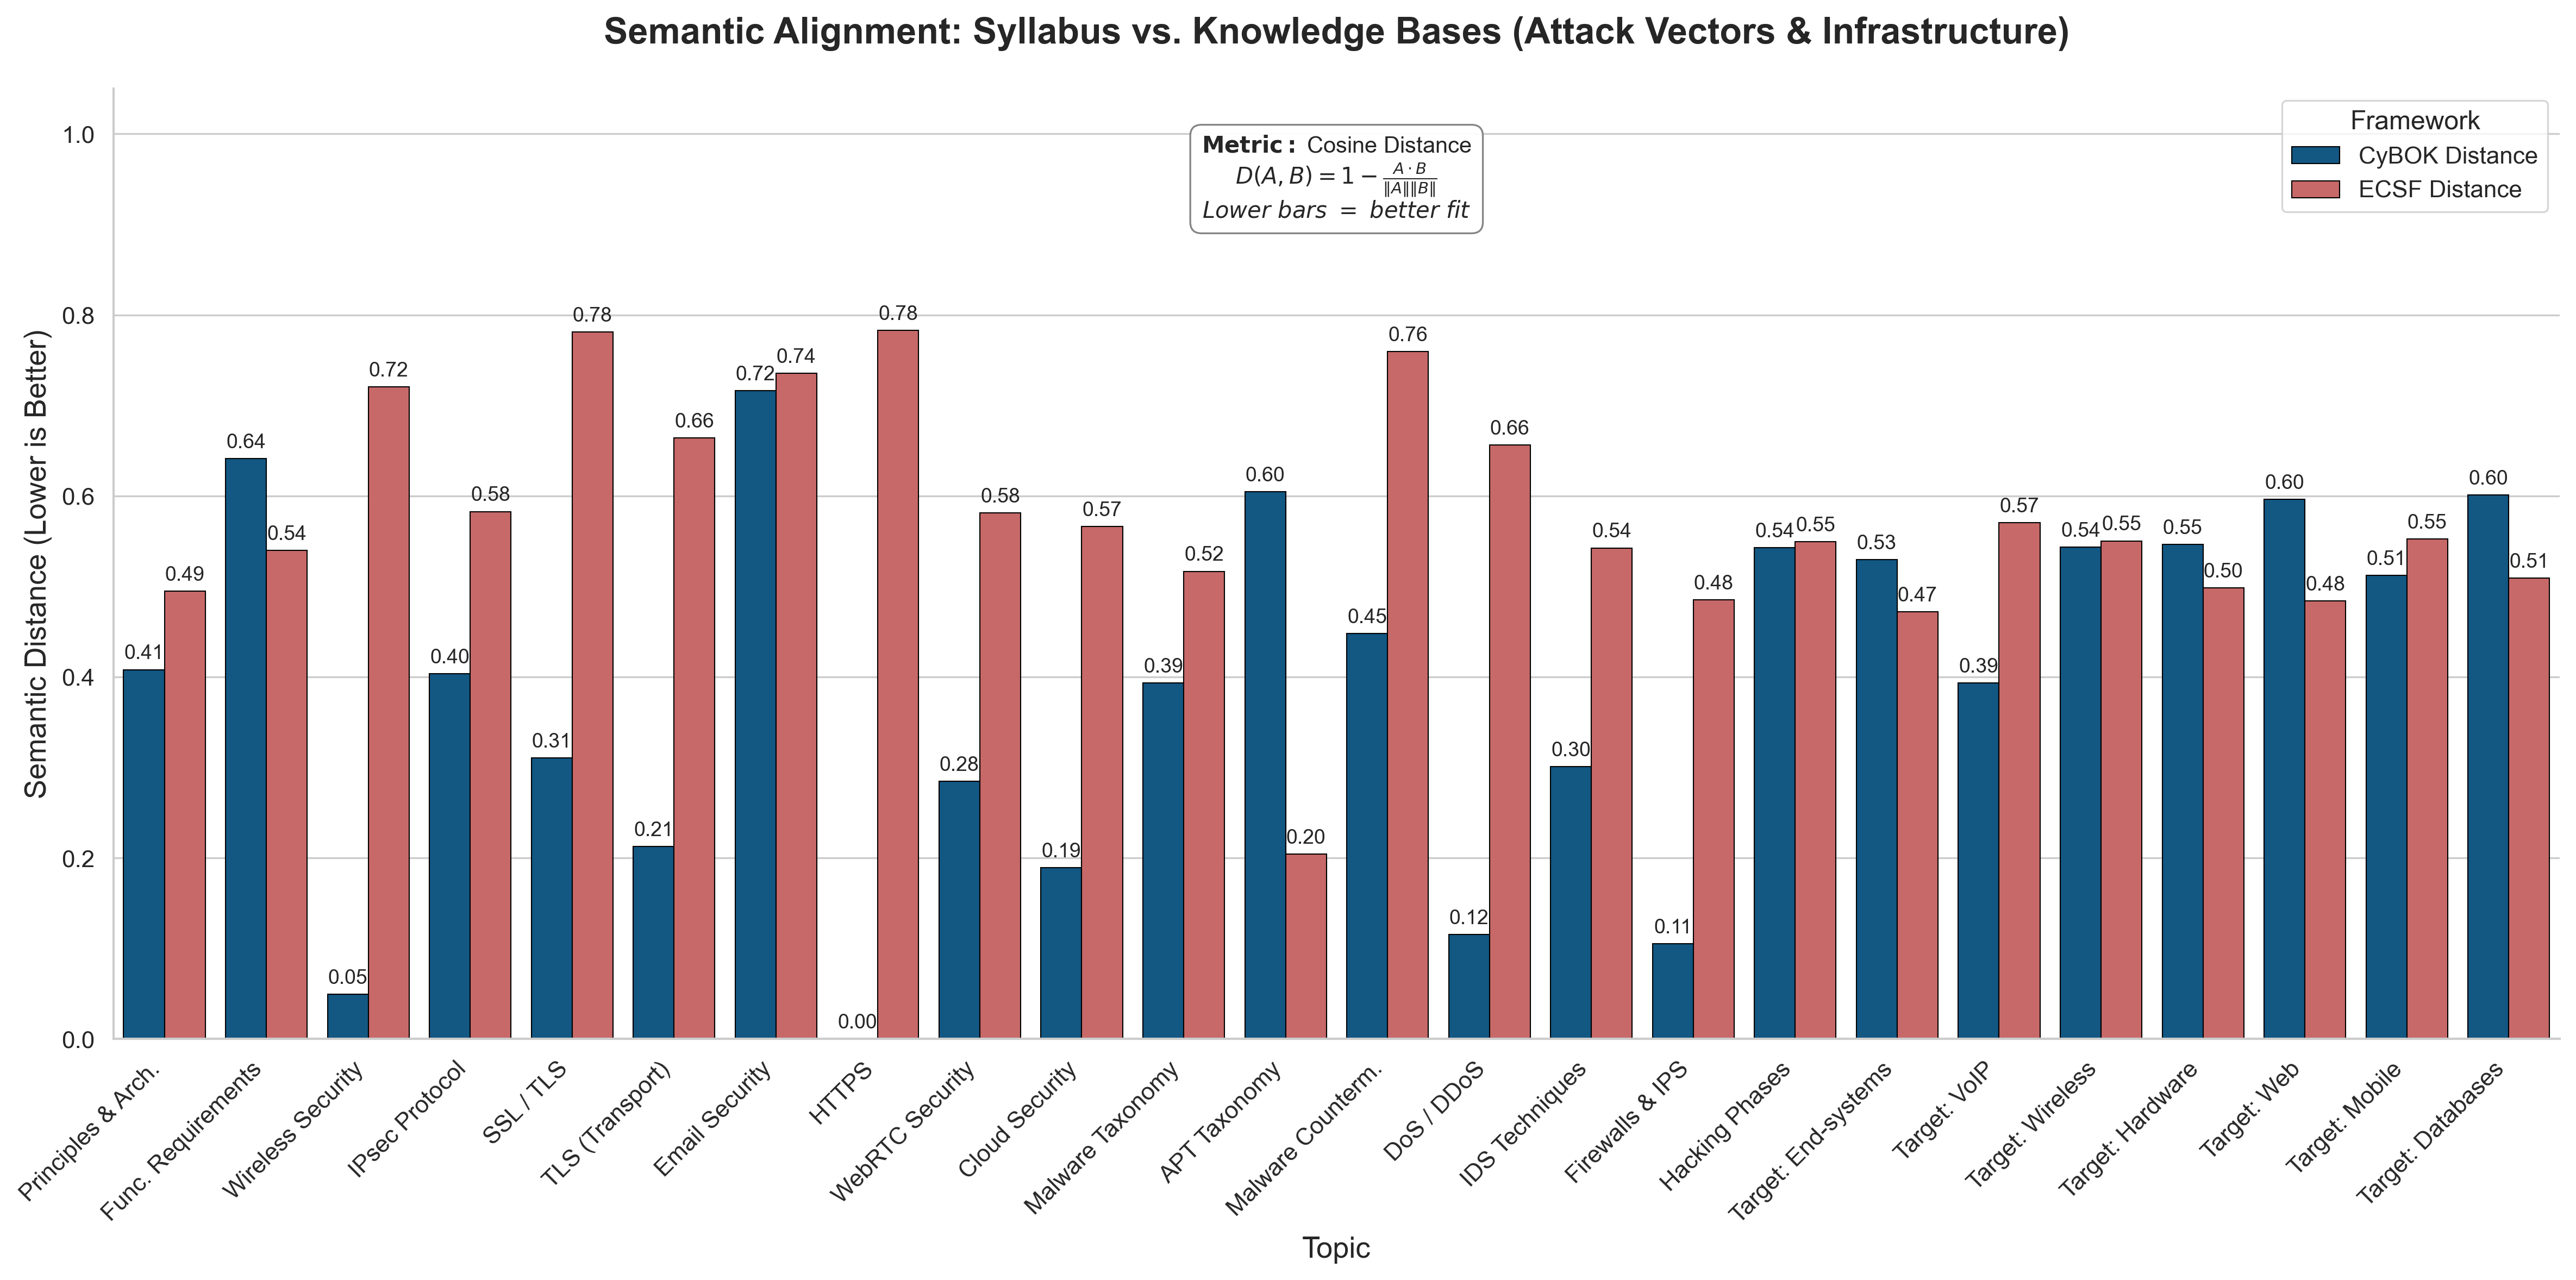

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
import numpy as np

model_name = 'all-mpnet-base-v2'
print(f"Caricamento del modello: {model_name}...")
model = SentenceTransformer(model_name)

dataset = [
    {
        "label": "Principles & Arch.",
        "syllabus_text": "Network Security: Principles and architecture",
        "cybok_candidates": ["Protection of information systems", "Protection of data", "Protection of services", "Unauthorised access, harm or misuse"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Cybersecurity recommendations and best practices", "Offensive and defensive security practices", "Offensive and defensive security procedures", "Security architecture reference models"]
    },
    {
        "label": "Func. Requirements",
        "syllabus_text": "Network Security: Functional security requirements",
        "cybok_candidates": ["Mitigate against failures & incidents"],
        "ecsf_candidates": ["Cybersecurity recommendations and best practices", "Offensive and defensive security practices", "Offensive and defensive security procedures"]
    },
    {
        "label": "Wireless Security",
        "syllabus_text": "Wireless Network Security",
        "cybok_candidates": ["Wireless Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "IPsec Protocol",
        "syllabus_text": "Network-level security: The IPsec protocol suite",
        "cybok_candidates": ["VPNs and IPsec"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "SSL / TLS",
        "syllabus_text": "Transport-level security: Secure Socket Layer (SSL)",
        "cybok_candidates": ["TLS", "Transport Layer Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "TLS (Transport)",
        "syllabus_text": "Transport-level security: Transport Security Layer (TLS)",
        "cybok_candidates": ["TLS", "Transport Layer Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Email Security",
        "syllabus_text": "Application-level security: e-mail",
        "cybok_candidates": ["Mitigations", "Phishing > Anti-phishing training"],
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity awareness, education and training programme development"]
    },
    {
        "label": "HTTPS",
        "syllabus_text": "HTTPS",
        "cybok_candidates": ["HTTPS"],
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "WebRTC Security",
        "syllabus_text": "Application-level security, Web: Security Architectures of Web Real Time Communication (WebRTC)",
        "cybok_candidates": ["WebRTCSecurity"], # Nota: Se 'WebRTCSecurity' è una singola parola nel CyBOK, va bene.
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Cloud Security",
        "syllabus_text": "Cloud Computing and security",
        "cybok_candidates": ["Cloud and data center security"],
        "ecsf_candidates": ["Computer networks security"]
    },
    {
        "label": "Malware Taxonomy",
        "syllabus_text": "Introduction to Malware, Taxonomy: Viruses, worms, trojans, rootkits, etc.",
        "cybok_candidates": ["Viruses", "Malicious browser extensions", "Botnet malware", "Memory-resident malware", "Advanced persistent threats", "Potentially unwanted programs"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Advanced and persistent cyber threats (APT)"]
    },{
        "label": "APT Taxonomy",
        "syllabus_text": "Introduction to Malware, Taxonomy: Advanced Persistent Threats (APTs)",
        "cybok_candidates": ["APT"],
        "ecsf_candidates": ["Advanced and persistent cyber threats (APT)"]
    },
    {
        "label": "Malware Counterm.",
        "syllabus_text": "Introduction to Malware: Countermeasures",
        "cybok_candidates": ["Identifying the presence of malware"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation"]
    },
    {
        "label": "DoS / DDoS",
        "syllabus_text": "Denial of Service (DoS) and Distributed Denial of Service (DDoS) Attacks",
        "cybok_candidates": ["Denial of service (DoS)"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation"]
    },
    {
        "label": "IDS Techniques",
        "syllabus_text": "Intrusion Detection Systems (IDS): Host-based, network-based, and hybrid techniques",
        "cybok_candidates": ["Intrusion Prevention System (IPS)", "Intrusion detection"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Firewalls & IPS",
        "syllabus_text": "Firewalls and Intrusion Prevention Systems (IPS)",
        "cybok_candidates": ["Intrusion Prevention System (IPS)"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Hacking Phases",
        "syllabus_text": "Hacking in IP Networks, preliminary attack phases: Footprinting , Scanning, Enumeration",
        "cybok_candidates": ["Attack surface", "Reconnaissance"],
        "ecsf_candidates": ["Offensive and defensive security practices", "Offensive and defensive security procedures", "Penetration testing procedures", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: End-systems",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques: Against end-systems and servers",
        "cybok_candidates": ["Security Goals in Networked Systems", "Server side vulnerabilities mitigations"],
        "ecsf_candidates": ["Cyber threat actors", "Cyber threats", "Cybersecurity attack procedures", "Cybersecurity risks", "Threat actors Tactics, Techniques and Procedures (TTPs)", "Computer systems vulnerabilities", "Penetration testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: VoIP",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: VoIP Networks",
        "cybok_candidates": ["VoIP networks"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Target: Wireless",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: Wireless Networks",
        "cybok_candidates": ["Wireless Networks"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Target: Hardware",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: Hardware Systems",
        "cybok_candidates": ["Hardware Security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Web",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Web",
        "cybok_candidates": ["Web & mobile security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Mobile",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Mobile Devices",
        "cybok_candidates": ["Web & mobile security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Databases",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Databases",
        "cybok_candidates": ["Databases"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    }
]

results = []

print("\n" + "="*120)
print(f"{'TOPIC (Short)':<20} | {'CyBOK Dist':<10} | {'ECSF Dist':<10} | {'DELTA (CyBOK Advantage)'}")
print("="*120)

for item in dataset:
    emb_syl = model.encode(item['syllabus_text'], convert_to_tensor=True)
    emb_cyb = model.encode(item['cybok_candidates'], convert_to_tensor=True)
    emb_ecsf = model.encode(item['ecsf_candidates'], convert_to_tensor=True)
    
    sim_cyb = util.cos_sim(emb_syl, emb_cyb).max().item()
    sim_ecsf = util.cos_sim(emb_syl, emb_ecsf).max().item()
    
    dist_cyb = 1 - sim_cyb
    dist_ecsf = 1 - sim_ecsf
    
    delta = dist_ecsf - dist_cyb # Se positivo, CyBOK è migliore
    
    results.append({
        "Topic": item['label'],
        "CyBOK Distance": dist_cyb,
        "ECSF Distance": dist_ecsf
    })
    
    print(f"{item['label']:<20} | {dist_cyb:.4f}     | {dist_ecsf:.4f}     | {delta:+.4f} {'✅' if delta > 0 else ''}")

df = pd.DataFrame(results)
df_melted = df.melt(id_vars=["Topic"], value_vars=["CyBOK Distance", "ECSF Distance"], 
                    var_name="Framework", value_name="Distance")

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(16, 8), dpi=300) 
custom_palette = {"CyBOK Distance": "#005b96", "ECSF Distance": "#d65a5a"}

ax = sns.barplot(
    data=df_melted, x="Topic", y="Distance", hue="Framework",
    palette=custom_palette, edgecolor="black", linewidth=0.5
)

plt.title("Semantic Alignment: Syllabus vs. Knowledge Bases (Attack Vectors & Infrastructure)", fontsize=16, weight='bold', pad=20)
plt.ylabel("Semantic Distance (Lower is Better)", fontsize=13)
plt.xlabel("Topic", fontsize=13)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right') 

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9, rotation=0)

math_text = (
    r"$\bf{Metric:}$ Cosine Distance" + "\n"
    r"$D(A,B) = 1 - \frac{A \cdot B}{\|A\| \|B\|}$" + "\n"
    r"$\it{Lower\ bars\ = \ better\ fit}$"
)
plt.text(
    x=0.5, y=0.95, s=math_text, transform=ax.transAxes,
    fontsize=10, verticalalignment='top', horizontalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.95, edgecolor='gray')
)

plt.legend(title="Framework", loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

Inizializzo TF-IDF vectorizer...

TOPIC (Short)        | CyBOK Dist | ECSF Dist  | DELTA (CyBOK Advantage)
Principles & Arch.   | 1.0000     | 0.8117     | -0.1883 
Func. Requirements   | 1.0000     | 0.8605     | -0.1395 
Wireless Security    | 0.6137     | 1.0000     | +0.3863 ✅
IPsec Protocol       | 0.8893     | 1.0000     | +0.1107 ✅
SSL / TLS            | 0.7246     | 1.0000     | +0.2754 ✅
TLS (Transport)      | 0.5651     | 1.0000     | +0.4349 ✅
Email Security       | 1.0000     | 1.0000     | +0.0000 
HTTPS                | 0.0000     | 1.0000     | +1.0000 ✅
WebRTC Security      | 1.0000     | 1.0000     | +0.0000 
Cloud Security       | 0.8078     | 0.9156     | +0.1078 ✅
Malware Taxonomy     | 0.7587     | 1.0000     | +0.2413 ✅
APT Taxonomy         | 1.0000     | 0.7380     | -0.2620 
Malware Counterm.    | 0.8737     | 1.0000     | +0.1263 ✅
DoS / DDoS           | 0.2997     | 1.0000     | +0.7003 ✅
IDS Techniques       | 0.6967     | 1.0000     | +0.3033 ✅
Firewalls & I

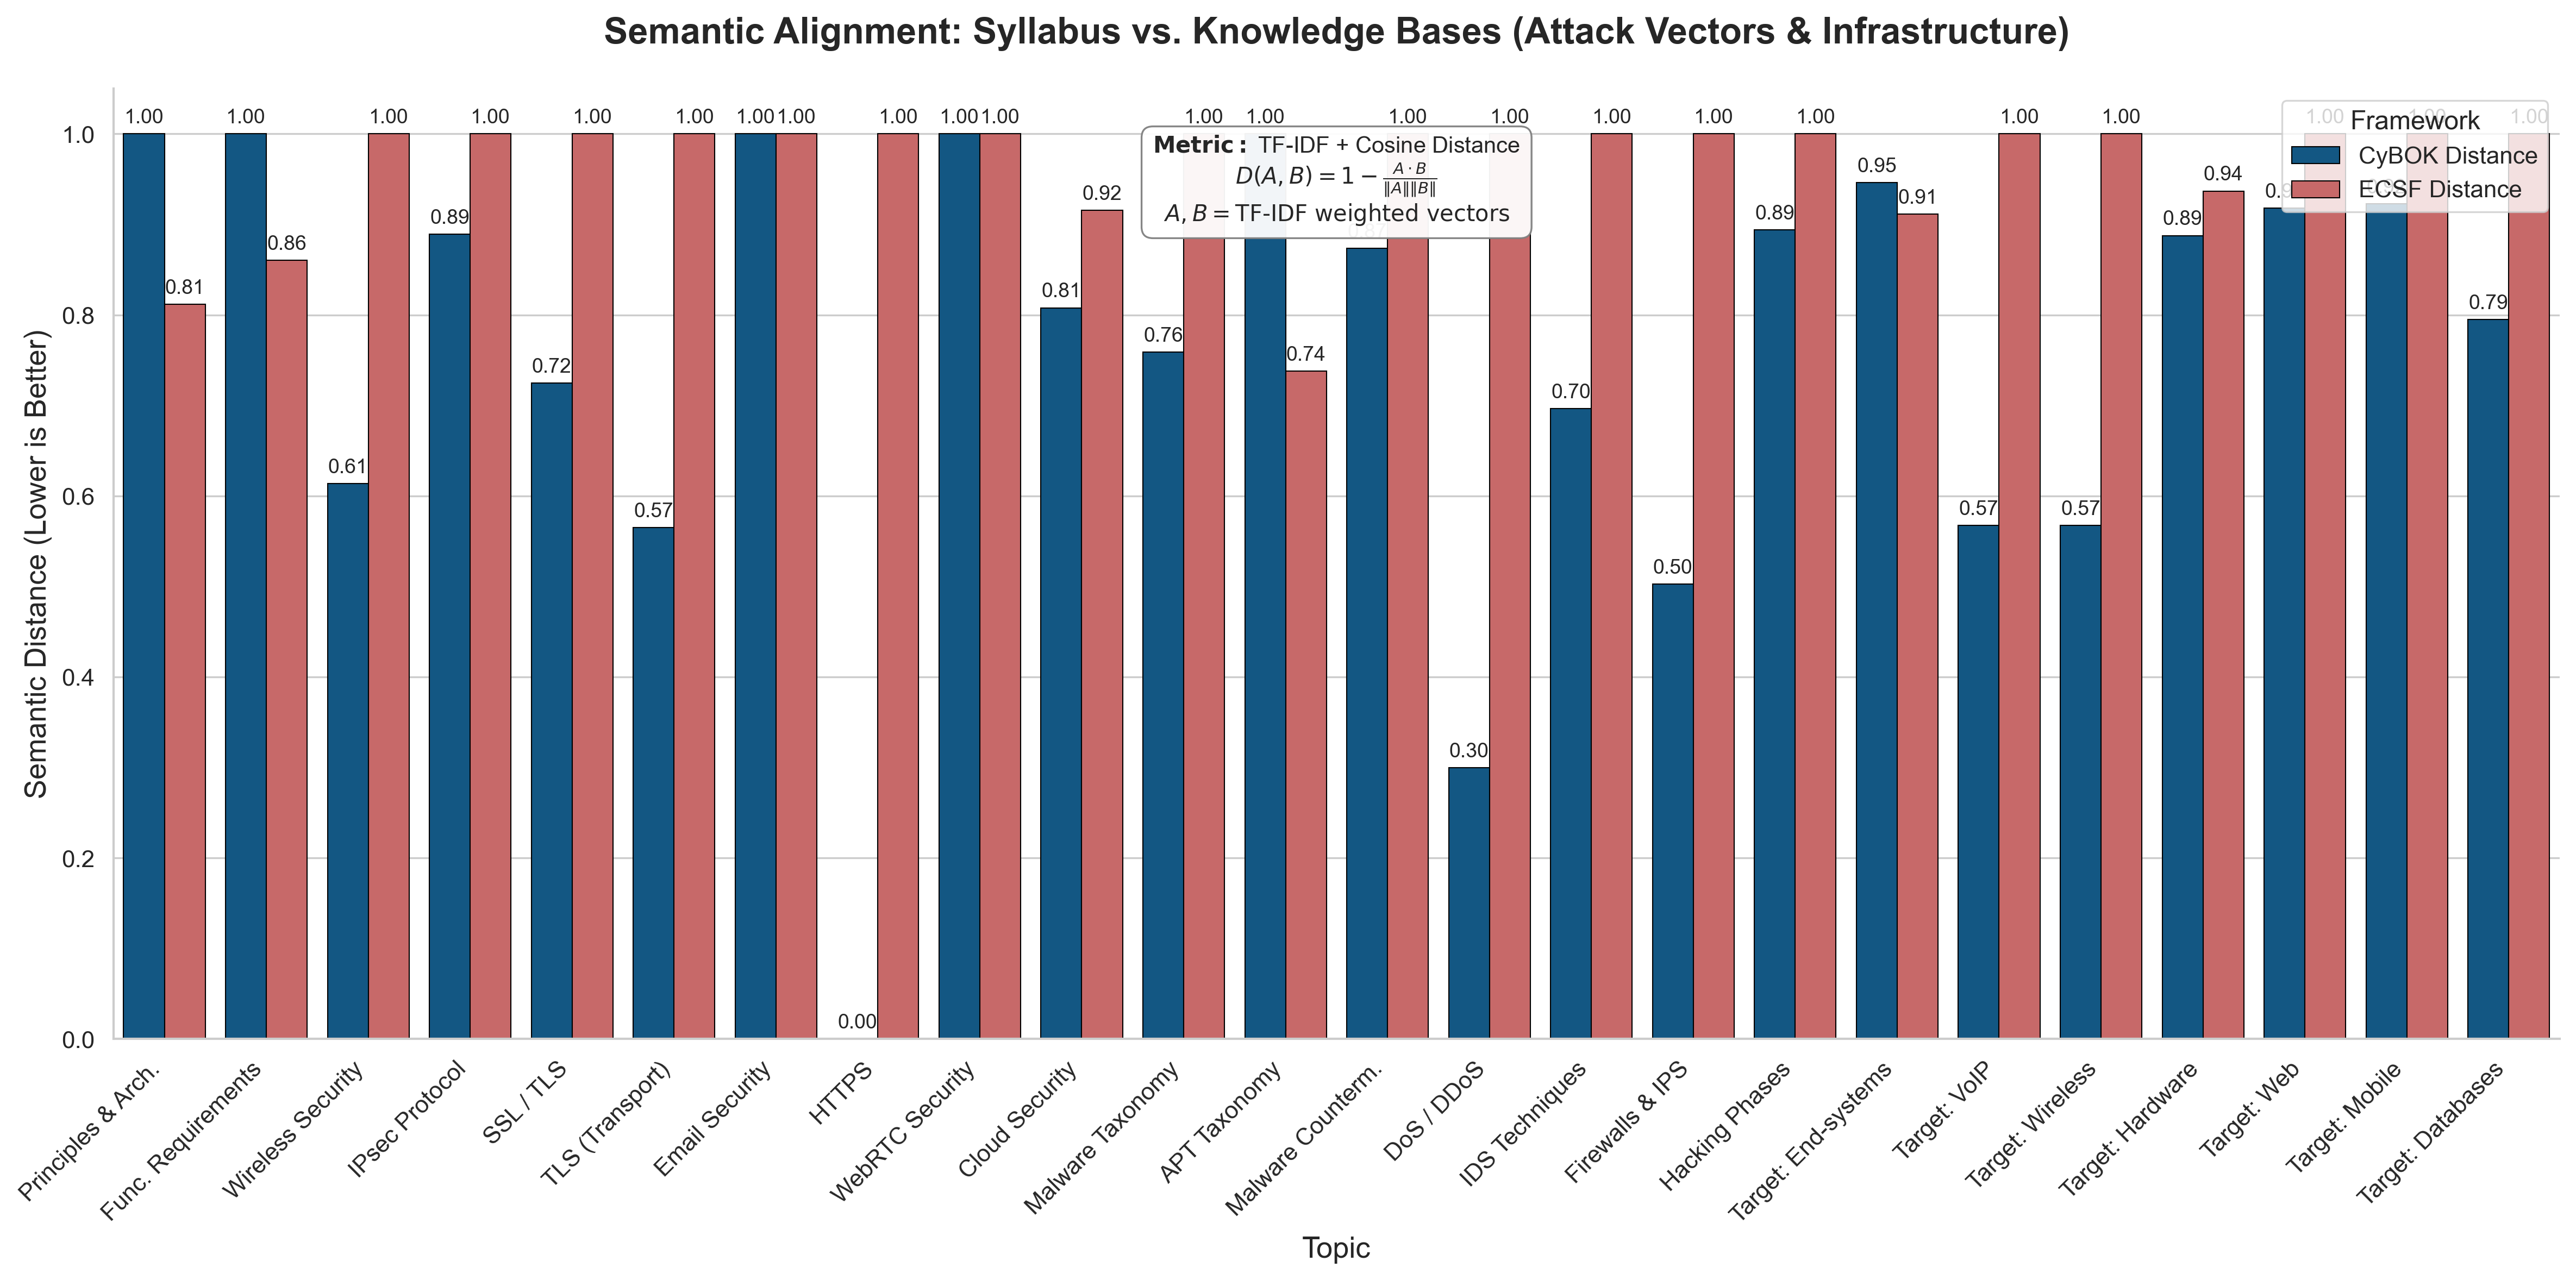

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Inizializzo TF-IDF vectorizer...")
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2)   
)


dataset = [
    {
        "label": "Principles & Arch.",
        "syllabus_text": "Network Security: Principles and architecture",
        "cybok_candidates": ["Protection of information systems", "Protection of data", "Protection of services", "Unauthorised access, harm or misuse"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Cybersecurity recommendations and best practices", "Offensive and defensive security practices", "Offensive and defensive security procedures", "Security architecture reference models"]
    },
    {
        "label": "Func. Requirements",
        "syllabus_text": "Network Security: Functional security requirements",
        "cybok_candidates": ["Mitigate against failures & incidents"],
        "ecsf_candidates": ["Cybersecurity recommendations and best practices", "Offensive and defensive security practices", "Offensive and defensive security procedures"]
    },
    {
        "label": "Wireless Security",
        "syllabus_text": "Wireless Network Security",
        "cybok_candidates": ["Wireless Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "IPsec Protocol",
        "syllabus_text": "Network-level security: The IPsec protocol suite",
        "cybok_candidates": ["VPNs and IPsec"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "SSL / TLS",
        "syllabus_text": "Transport-level security: Secure Socket Layer (SSL)",
        "cybok_candidates": ["TLS", "Transport Layer Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "TLS (Transport)",
        "syllabus_text": "Transport-level security: Transport Security Layer (TLS)",
        "cybok_candidates": ["TLS", "Transport Layer Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Email Security",
        "syllabus_text": "Application-level security: e-mail",
        "cybok_candidates": ["Mitigations", "Phishing > Anti-phishing training"],
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity awareness, education and training programme development"]
    },
    {
        "label": "HTTPS",
        "syllabus_text": "HTTPS",
        "cybok_candidates": ["HTTPS"],
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "WebRTC Security",
        "syllabus_text": "Application-level security, Web: Security Architectures of Web Real Time Communication (WebRTC)",
        "cybok_candidates": ["WebRTCSecurity"], # Nota: Se 'WebRTCSecurity' è una singola parola nel CyBOK, va bene.
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Cloud Security",
        "syllabus_text": "Cloud Computing and security",
        "cybok_candidates": ["Cloud and data center security"],
        "ecsf_candidates": ["Computer networks security"]
    },
    {
        "label": "Malware Taxonomy",
        "syllabus_text": "Introduction to Malware, Taxonomy: Viruses, worms, trojans, rootkits, etc.",
        "cybok_candidates": ["Viruses", "Malicious browser extensions", "Botnet malware", "Memory-resident malware", "Advanced persistent threats", "Potentially unwanted programs"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Advanced and persistent cyber threats (APT)"]
    },{
        "label": "APT Taxonomy",
        "syllabus_text": "Introduction to Malware, Taxonomy: Advanced Persistent Threats (APTs)",
        "cybok_candidates": ["APT"],
        "ecsf_candidates": ["Advanced and persistent cyber threats (APT)"]
    },
    {
        "label": "Malware Counterm.",
        "syllabus_text": "Introduction to Malware: Countermeasures",
        "cybok_candidates": ["Identifying the presence of malware"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation"]
    },
    {
        "label": "DoS / DDoS",
        "syllabus_text": "Denial of Service (DoS) and Distributed Denial of Service (DDoS) Attacks",
        "cybok_candidates": ["Denial of service (DoS)"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation"]
    },
    {
        "label": "IDS Techniques",
        "syllabus_text": "Intrusion Detection Systems (IDS): Host-based, network-based, and hybrid techniques",
        "cybok_candidates": ["Intrusion Prevention System (IPS)", "Intrusion detection"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Firewalls & IPS",
        "syllabus_text": "Firewalls and Intrusion Prevention Systems (IPS)",
        "cybok_candidates": ["Intrusion Prevention System (IPS)"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Hacking Phases",
        "syllabus_text": "Hacking in IP Networks, preliminary attack phases: Footprinting , Scanning, Enumeration",
        "cybok_candidates": ["Attack surface", "Reconnaissance"],
        "ecsf_candidates": ["Offensive and defensive security practices", "Offensive and defensive security procedures", "Penetration testing procedures", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: End-systems",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques: Against end-systems and servers",
        "cybok_candidates": ["Security Goals in Networked Systems", "Server side vulnerabilities mitigations"],
        "ecsf_candidates": ["Cyber threat actors", "Cyber threats", "Cybersecurity attack procedures", "Cybersecurity risks", "Threat actors Tactics, Techniques and Procedures (TTPs)", "Computer systems vulnerabilities", "Penetration testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: VoIP",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: VoIP Networks",
        "cybok_candidates": ["VoIP networks"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Target: Wireless",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: Wireless Networks",
        "cybok_candidates": ["Wireless Networks"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Target: Hardware",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: Hardware Systems",
        "cybok_candidates": ["Hardware Security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Web",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Web",
        "cybok_candidates": ["Web & mobile security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Mobile",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Mobile Devices",
        "cybok_candidates": ["Web & mobile security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Databases",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Databases",
        "cybok_candidates": ["Databases"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    }
]

results = []

print("\n" + "="*120)
print(f"{'TOPIC (Short)':<20} | {'CyBOK Dist':<10} | {'ECSF Dist':<10} | {'DELTA (CyBOK Advantage)'}")
print("="*120)

for item in dataset:
    
    texts = (
        [item["syllabus_text"]] +
        item["cybok_candidates"] +
        item["ecsf_candidates"]
    )

    X = vectorizer.fit_transform(texts)

    v_syl = X[0]

    v_cyb = X[1 : 1 + len(item["cybok_candidates"])]
    v_ecsf = X[1 + len(item["cybok_candidates"]) : ]

    sim_cyb = cosine_similarity(v_syl, v_cyb).max()
    sim_ecsf = cosine_similarity(v_syl, v_ecsf).max()
    
    dist_cyb = 1 - sim_cyb
    dist_ecsf = 1 - sim_ecsf
    
    delta = dist_ecsf - dist_cyb 
    
    results.append({
        "Topic": item['label'],
        "CyBOK Distance": dist_cyb,
        "ECSF Distance": dist_ecsf
    })
    
    print(f"{item['label']:<20} | {dist_cyb:.4f}     | {dist_ecsf:.4f}     | {delta:+.4f} {'✅' if delta > 0 else ''}")

df = pd.DataFrame(results)
df_melted = df.melt(id_vars=["Topic"], value_vars=["CyBOK Distance", "ECSF Distance"], 
                    var_name="Framework", value_name="Distance")

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(16, 8), dpi=300) 
custom_palette = {"CyBOK Distance": "#005b96", "ECSF Distance": "#d65a5a"}

ax = sns.barplot(
    data=df_melted, x="Topic", y="Distance", hue="Framework",
    palette=custom_palette, edgecolor="black", linewidth=0.5
)

plt.title("Semantic Alignment: Syllabus vs. Knowledge Bases (Attack Vectors & Infrastructure)", fontsize=16, weight='bold', pad=20)
plt.ylabel("Semantic Distance (Lower is Better)", fontsize=13)
plt.xlabel("Topic", fontsize=13)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right') 

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9, rotation=0)

math_text = (
    r"$\bf{Metric:}$ TF-IDF + Cosine Distance" + "\n"
    r"$D(A,B) = 1 - \frac{A \cdot B}{\|A\| \|B\|}$" + "\n"
    r"$A,B = \text{TF-IDF weighted vectors}$"
)

plt.text(
    x=0.5, y=0.95, s=math_text, transform=ax.transAxes,
    fontsize=10, verticalalignment='top', horizontalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.95, edgecolor='gray')
)

plt.legend(title="Framework", loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

Computing Metrics...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14551.62it/s]


Wilcoxon Test Result (Embeddings): p-value = 0.00326
Generato: Fig1_GapAnalysis_Zones.pdf
Generato: Fig2_Sensitivity_Explicit.pdf

--- LATEX: TABLE 1 (DEFINITIONS) ---
\begin{tabular}{@{}lp{8cm}@{}}\toprule
\toprule
\midrule
Label & Syllabus Text \\
\midrule
Principles \& Arch. & Network Security: Principles and architecture \\
Func. Requirements & Network Security: Functional security requirements \\
Wireless Security & Wireless Network Security \\
IPsec Protocol & Network-level security: The IPsec protocol suite \\
SSL / TLS & Transport-level security: Secure Socket Layer (SSL) \\
TLS (Transport) & Transport-level security: Transport Security Layer (TLS) \\
Email Security & Application-level security: e-mail \\
HTTPS & HTTPS \\
WebRTC Security & Application-level security, Web: Security Architectures of Web Real Time Communication (WebRTC) \\
Cloud Security & Cloud Computing and security \\
Malware Taxonomy & Introduction to Malware, Taxonomy: Viruses, worms, trojans, rootkits, etc. 

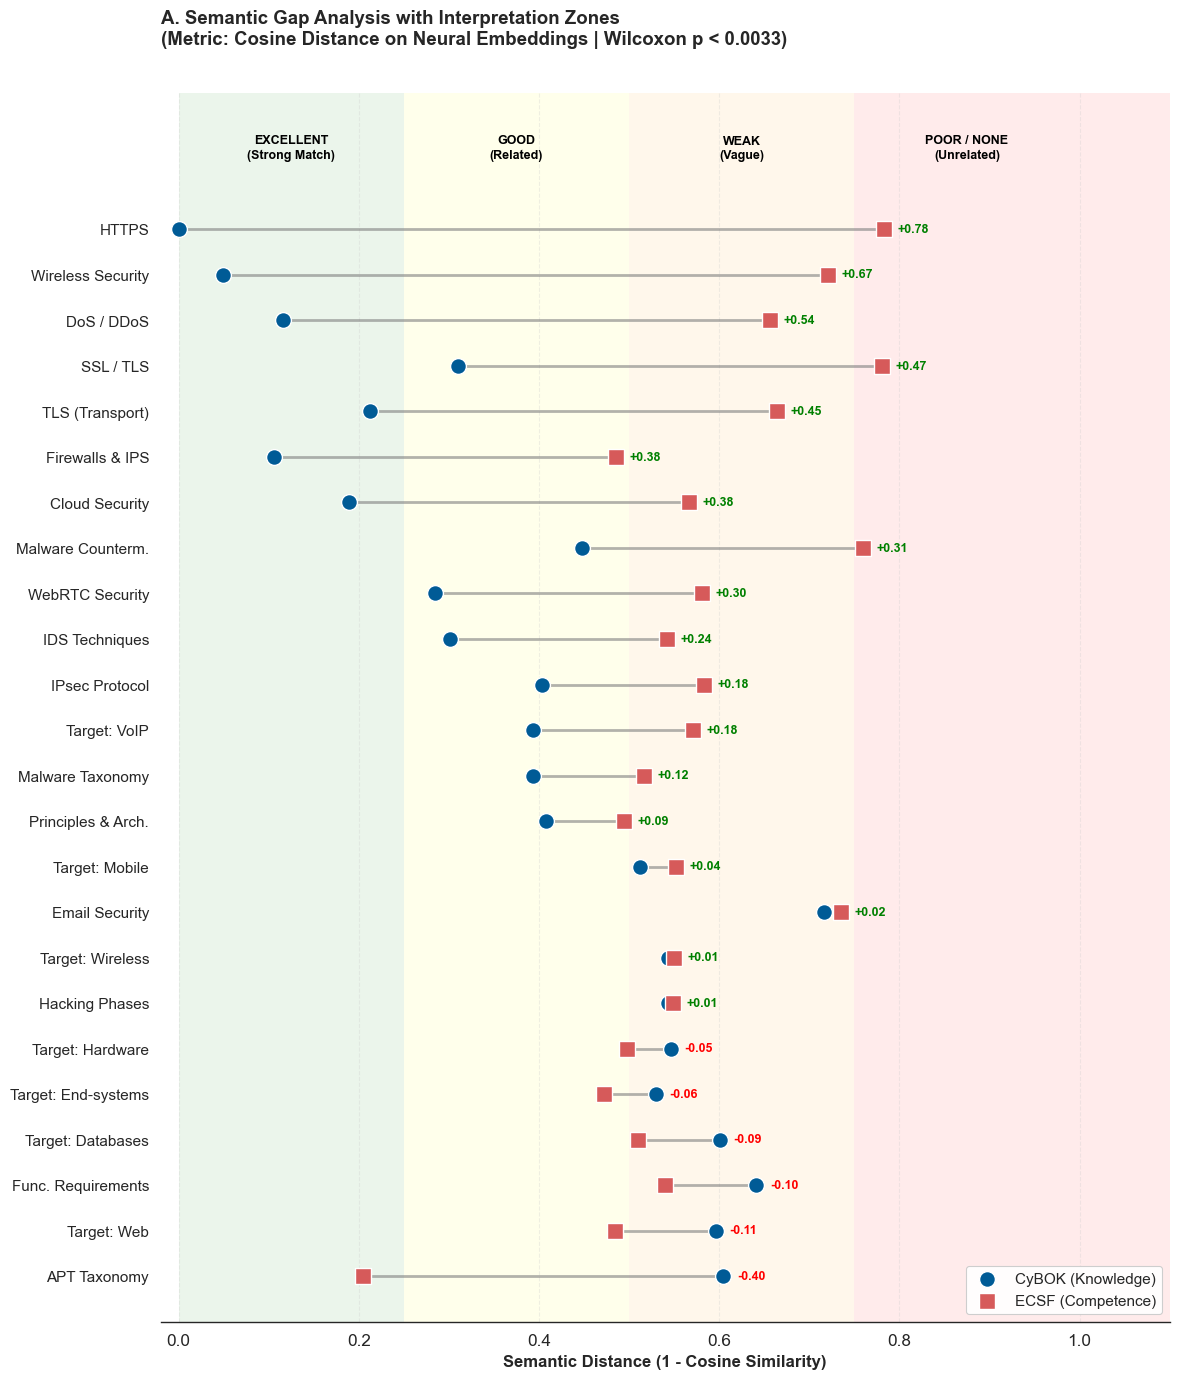

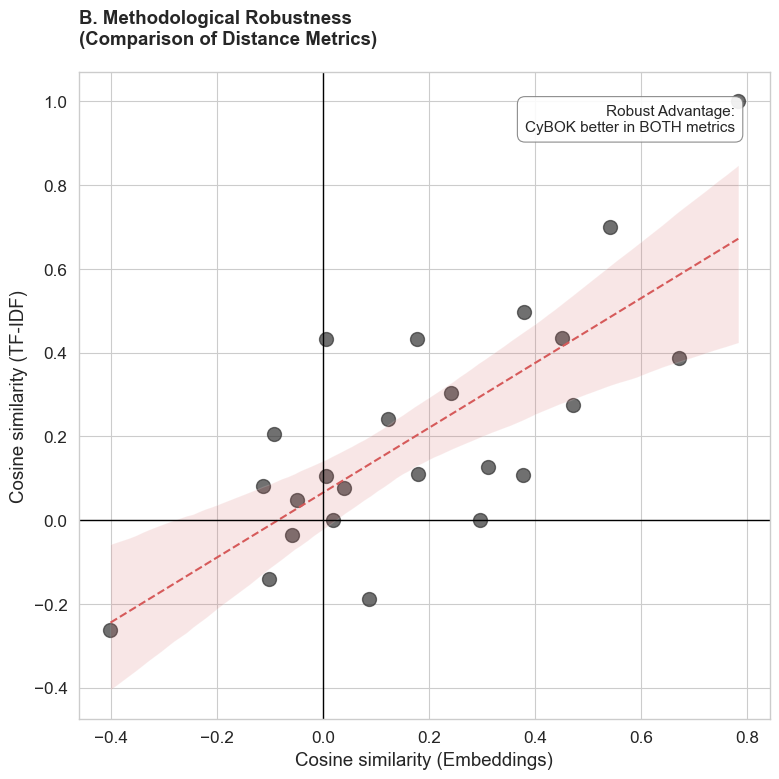

In [ ]:
dataset = [
    {
        "label": "Principles & Arch.",
        "syllabus_text": "Network Security: Principles and architecture",
        "cybok_candidates": ["Protection of information systems", "Protection of data", "Protection of services", "Unauthorised access, harm or misuse"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Cybersecurity recommendations and best practices", "Offensive and defensive security practices", "Offensive and defensive security procedures", "Security architecture reference models"]
    },
    {
        "label": "Func. Requirements",
        "syllabus_text": "Network Security: Functional security requirements",
        "cybok_candidates": ["Mitigate against failures & incidents"],
        "ecsf_candidates": ["Cybersecurity recommendations and best practices", "Offensive and defensive security practices", "Offensive and defensive security procedures"]
    },
    {
        "label": "Wireless Security",
        "syllabus_text": "Wireless Network Security",
        "cybok_candidates": ["Wireless Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "IPsec Protocol",
        "syllabus_text": "Network-level security: The IPsec protocol suite",
        "cybok_candidates": ["VPNs and IPsec"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "SSL / TLS",
        "syllabus_text": "Transport-level security: Secure Socket Layer (SSL)",
        "cybok_candidates": ["TLS", "Transport Layer Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "TLS (Transport)",
        "syllabus_text": "Transport-level security: Transport Security Layer (TLS)",
        "cybok_candidates": ["TLS", "Transport Layer Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Email Security",
        "syllabus_text": "Application-level security: e-mail",
        "cybok_candidates": ["Mitigations", "Phishing > Anti-phishing training"],
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity awareness, education and training programme development"]
    },
    {
        "label": "HTTPS",
        "syllabus_text": "HTTPS",
        "cybok_candidates": ["HTTPS"],
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "WebRTC Security",
        "syllabus_text": "Application-level security, Web: Security Architectures of Web Real Time Communication (WebRTC)",
        "cybok_candidates": ["WebRTCSecurity"], # Nota: Se 'WebRTCSecurity' è una singola parola nel CyBOK, va bene.
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Cloud Security",
        "syllabus_text": "Cloud Computing and security",
        "cybok_candidates": ["Cloud and data center security"],
        "ecsf_candidates": ["Computer networks security"]
    },
    {
        "label": "Malware Taxonomy",
        "syllabus_text": "Introduction to Malware, Taxonomy: Viruses, worms, trojans, rootkits, etc.",
        "cybok_candidates": ["Viruses", "Malicious browser extensions", "Botnet malware", "Memory-resident malware", "Advanced persistent threats", "Potentially unwanted programs"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Advanced and persistent cyber threats (APT)"]
    },{
        "label": "APT Taxonomy",
        "syllabus_text": "Introduction to Malware, Taxonomy: Advanced Persistent Threats (APTs)",
        "cybok_candidates": ["APT"],
        "ecsf_candidates": ["Advanced and persistent cyber threats (APT)"]
    },
    {
        "label": "Malware Counterm.",
        "syllabus_text": "Introduction to Malware: Countermeasures",
        "cybok_candidates": ["Identifying the presence of malware"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation"]
    },
    {
        "label": "DoS / DDoS",
        "syllabus_text": "Denial of Service (DoS) and Distributed Denial of Service (DDoS) Attacks",
        "cybok_candidates": ["Denial of service (DoS)"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation"]
    },
    {
        "label": "IDS Techniques",
        "syllabus_text": "Intrusion Detection Systems (IDS): Host-based, network-based, and hybrid techniques",
        "cybok_candidates": ["Intrusion Prevention System (IPS)", "Intrusion detection"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Firewalls & IPS",
        "syllabus_text": "Firewalls and Intrusion Prevention Systems (IPS)",
        "cybok_candidates": ["Intrusion Prevention System (IPS)"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Hacking Phases",
        "syllabus_text": "Hacking in IP Networks, preliminary attack phases: Footprinting , Scanning, Enumeration",
        "cybok_candidates": ["Attack surface", "Reconnaissance"],
        "ecsf_candidates": ["Offensive and defensive security practices", "Offensive and defensive security procedures", "Penetration testing procedures", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: End-systems",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques: Against end-systems and servers",
        "cybok_candidates": ["Security Goals in Networked Systems", "Server side vulnerabilities mitigations"],
        "ecsf_candidates": ["Cyber threat actors", "Cyber threats", "Cybersecurity attack procedures", "Cybersecurity risks", "Threat actors Tactics, Techniques and Procedures (TTPs)", "Computer systems vulnerabilities", "Penetration testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: VoIP",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: VoIP Networks",
        "cybok_candidates": ["VoIP networks"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Target: Wireless",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: Wireless Networks",
        "cybok_candidates": ["Wireless Networks"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Target: Hardware",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: Hardware Systems",
        "cybok_candidates": ["Hardware Security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Web",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Web",
        "cybok_candidates": ["Web & mobile security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Mobile",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Mobile Devices",
        "cybok_candidates": ["Web & mobile security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Databases",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Databases",
        "cybok_candidates": ["Databases"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    }
]

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, util

sns.set_theme(style="white", context="paper", font_scale=1.4) # Uso "white" per le bande colorate
BLUE_COLOR = '#005b96'
RED_COLOR = '#d65a5a'


print("Computing Metrics...")
model = SentenceTransformer('all-mpnet-base-v2')
vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1,2))

results = []
mapping_table = [] 

for item in dataset:
    mapping_table.append({
        "Label": item['label'],
        "Syllabus Text": item['syllabus_text']
    })


    s_emb = model.encode(item['syllabus_text'], convert_to_tensor=True)
    c_emb = model.encode(item['cybok_candidates'], convert_to_tensor=True)
    e_emb = model.encode(item['ecsf_candidates'], convert_to_tensor=True)
    # Distance = 1 - Cosine Similarity
    d_cyb_emb = 1 - util.cos_sim(s_emb, c_emb).max().item()
    d_ecsf_emb = 1 - util.cos_sim(s_emb, e_emb).max().item()
    
    # 2. TF-IDF (Cosine Distance)
    texts = [item["syllabus_text"]] + item["cybok_candidates"] + item["ecsf_candidates"]
    X = vectorizer.fit_transform(texts)
    v_syl = X[0]
    v_cyb = X[1 : 1 + len(item["cybok_candidates"])]
    v_ecsf = X[1 + len(item["cybok_candidates"]) : ]
    d_cyb_tfidf = 1 - cosine_similarity(v_syl, v_cyb).max()
    d_ecsf_tfidf = 1 - cosine_similarity(v_syl, v_ecsf).max()
    
    results.append({
        "Topic": item['label'],
        "CyBOK_Emb": d_cyb_emb, "ECSF_Emb": d_ecsf_emb,
        "CyBOK_TFIDF": d_cyb_tfidf, "ECSF_TFIDF": d_ecsf_tfidf
    })

df = pd.DataFrame(results)
df_mapping = pd.DataFrame(mapping_table)

# Calcolo Delta
df['Gap_Emb'] = df['ECSF_Emb'] - df['CyBOK_Emb']
df['Gap_TFIDF'] = df['ECSF_TFIDF'] - df['CyBOK_TFIDF']

# WILCOXON
stat_emb, p_emb = wilcoxon(df['CyBOK_Emb'], df['ECSF_Emb'], alternative='less')
print(f"Wilcoxon Test Result (Embeddings): p-value = {p_emb:.5f}")


# GAP ANALYSIS (DUMBBELL WITH ZONES)
fig1, ax1 = plt.subplots(figsize=(12, 14)) # Aumentata larghezza per ospitare le label
df_sorted = df.sort_values('Gap_Emb', ascending=True)
y_range = range(len(df_sorted))

# Aggiunta delle FASCE SEMANTICHE 
zones = [
    (0.00, 0.25, 'green', 'EXCELLENT\n(Strong Match)'),
    (0.25, 0.50, 'yellow', 'GOOD\n(Related)'),
    (0.50, 0.75, 'orange', 'WEAK\n(Vague)'),
    (0.75, 1.25, 'red', 'POOR / NONE\n(Unrelated)')
]

for start, end, color, label in zones:
    ax1.axvspan(start, end, color=color, alpha=0.08, zorder=0, lw=0)
    ax1.text((start + min(end, 1.0))/2, len(df_sorted) + 0.5, label, 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

ax1.hlines(y=y_range, xmin=df_sorted['CyBOK_Emb'], xmax=df_sorted['ECSF_Emb'], color='grey', alpha=0.6, linewidth=2, zorder=2)
ax1.scatter(df_sorted['CyBOK_Emb'], y_range, color=BLUE_COLOR, label='CyBOK (Knowledge)', s=130, zorder=3, edgecolors='white', linewidth=1)
ax1.scatter(df_sorted['ECSF_Emb'], y_range, color=RED_COLOR, label='ECSF (Competence)', s=130, zorder=3, marker='s', edgecolors='white', linewidth=1)

for i, (idx, row) in enumerate(df_sorted.iterrows()):
    gap = row['Gap_Emb']
    if gap >= 0: 
        ax1.text(row['ECSF_Emb'] + 0.015, i, f"+{gap:.2f}", va='center', fontsize=9, color='green', weight='bold')
    elif gap < 0: 
        ax1.text(row['CyBOK_Emb'] + 0.015, i, f"{gap:.2f}", va='center', fontsize=9, color='red', weight='bold')

ax1.set_yticks(y_range)
ax1.set_yticklabels(df_sorted['Topic'], fontsize=11)
ax1.set_xlabel('Semantic Distance (1 - Cosine Similarity)', fontsize=12, weight='bold')
ax1.set_title(f"A. Semantic Gap Analysis with Interpretation Zones\n(Metric: Cosine Distance on Neural Embeddings | Wilcoxon p < {p_emb:.4f})", loc='left', weight='bold', pad=35) 
ax1.legend(loc='lower right', frameon=True, fancybox=True, framealpha=0.95, fontsize=11)
ax1.set_xlim(-0.02, 1.1) 
ax1.set_ylim(-1, len(df_sorted)+2) 
sns.despine(left=True, bottom=False)
ax1.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
# plt.savefig("../../figs/Fig1_GapAnalysis_Zones.pdf", dpi=300, bbox_inches='tight')
print("Generato: Fig1_GapAnalysis_Zones.pdf")

# SENSITIVITY (SCATTER)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4) 
fig2, ax2 = plt.subplots(figsize=(8, 8))
sns.regplot(data=df, x='Gap_Emb', y='Gap_TFIDF', ax=ax2, color='#333333', 
            scatter_kws={'alpha':0.7, 's':100}, line_kws={'color':RED_COLOR, 'linestyle':'--', 'linewidth':1.5})
ax2.axvline(0, color='black', linewidth=1)
ax2.axhline(0, color='black', linewidth=1)
ax2.text(0.95, 0.95, "Robust Advantage:\nCyBOK better in BOTH metrics", 
         transform=ax2.transAxes, fontsize=11, ha='right', va='top',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

ax2.set_xlabel('Cosine similarity (Embeddings)')
ax2.set_ylabel('Cosine similarity (TF-IDF)')
ax2.set_title("B. Methodological Robustness\n(Comparison of Distance Metrics)", loc='left', weight='bold', pad=20)
plt.tight_layout()
plt.savefig("../../figs/Fig2_Sensitivity_Explicit.pdf", dpi=300)
print("Generato: Fig2_Sensitivity_Explicit.pdf")


def clean_latex(s):
    return str(s).replace("&", "\\&").replace("%", "\\%")

# TABLE 1
print("\n--- LATEX: TABLE 1 (DEFINITIONS) ---")
df_mapping['Label'] = df_mapping['Label'].apply(clean_latex)
df_mapping['Syllabus Text'] = df_mapping['Syllabus Text'].apply(clean_latex)

latex_table1 = df_mapping.to_latex(index=False, column_format="@{}lp{8cm}@{}")
lines1 = latex_table1.split('\n')
lines1[0] = "\\begin{tabular}{@{}lp{8cm}@{}}\\toprule"
lines1.insert(2, "\\midrule")
lines1[-1] = "\\bottomrule\\end{tabular}"
print("\n".join(lines1))

# TABLE 2
print("\n--- LATEX: TABLE 2 (RESULTS) ---")
df_results = df[['Topic', 'CyBOK_Emb', 'ECSF_Emb', 'Gap_Emb', 'Gap_TFIDF']].copy()
df_results['Topic'] = df_results['Topic'].apply(clean_latex)
df_results.columns = ["Topic Label", "CyBOK (Emb)", "ECSF (Emb)", "Gap (Emb)", "Robustness (TF-IDF Gap)"]

latex_table2 = df_results.to_latex(index=False, float_format="%.3f", column_format="@{}lcccc@{}")
lines2 = latex_table2.split('\n')
lines2[0] = "\\begin{tabular}{@{}lcccc@{}}\\toprule"
lines2.insert(2, "\\midrule")
lines2[-1] = "\\bottomrule\\end{tabular}"
print("\n".join(lines2))

1. Traduzione dei testi in vettori numerici (Embedding)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11622.13it/s]



2. Campione delle differenze calcolate (D_ECSF - D_CyBOK):
                Topic     Delta
0  Principles & Arch.  0.086662
1  Func. Requirements -0.101206
2   Wireless Security  0.670833
3      IPsec Protocol  0.179359
4           SSL / TLS  0.470532

3. VERIFICA DELLE ASSUNZIONI STATISTICHE


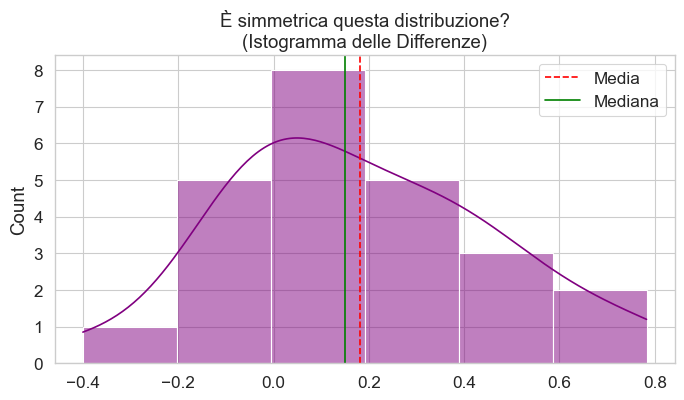


[Check 1] Asimmetria (Skewness): 0.2727
   -> ESITO: Eccellente. La distribuzione è molto simmetrica.

[Check 2] Shapiro-Wilk Test: p-value = 0.7966
   -> ESITO: Superato (p > 0.05). I dati sono compatibili con una distribuzione Normale (e quindi Simmetrica).

4. ESECUZIONE DEL TEST DI WILCOXON
Statistica W: 57.0
P-Value: 0.003258
Il p-value è molto basso (inferiore alla soglia critica del 5%).
Cosa significa? Che è estremamente improbabile che questo risultato sia dovuto al caso.
Possiamo affermare con confidenza scientifica che CyBOK mappa il Syllabus meglio di ECSF.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, skew, kurtosis
from sentence_transformers import SentenceTransformer, util

# --- 1. IL NOSTRO LABORATORIO DI DATI ---
# Perché partiamo da qui? 
# Prima di poter validare qualsiasi ipotesi, dobbiamo trasformare il testo (qualitativo) 
# in numeri (quantitativo). Senza numeri, la statistica è muta.
dataset = [
    {
        "label": "Principles & Arch.",
        "syllabus_text": "Network Security: Principles and architecture",
        "cybok_candidates": ["Protection of information systems", "Protection of data", "Protection of services", "Unauthorised access, harm or misuse"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Cybersecurity recommendations and best practices", "Offensive and defensive security practices", "Offensive and defensive security procedures", "Security architecture reference models"]
    },
    {
        "label": "Func. Requirements",
        "syllabus_text": "Network Security: Functional security requirements",
        "cybok_candidates": ["Mitigate against failures & incidents"],
        "ecsf_candidates": ["Cybersecurity recommendations and best practices", "Offensive and defensive security practices", "Offensive and defensive security procedures"]
    },
    {
        "label": "Wireless Security",
        "syllabus_text": "Wireless Network Security",
        "cybok_candidates": ["Wireless Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "IPsec Protocol",
        "syllabus_text": "Network-level security: The IPsec protocol suite",
        "cybok_candidates": ["VPNs and IPsec"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "SSL / TLS",
        "syllabus_text": "Transport-level security: Secure Socket Layer (SSL)",
        "cybok_candidates": ["TLS", "Transport Layer Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "TLS (Transport)",
        "syllabus_text": "Transport-level security: Transport Security Layer (TLS)",
        "cybok_candidates": ["TLS", "Transport Layer Security"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Email Security",
        "syllabus_text": "Application-level security: e-mail",
        "cybok_candidates": ["Mitigations", "Phishing > Anti-phishing training"],
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity awareness, education and training programme development"]
    },
    {
        "label": "HTTPS",
        "syllabus_text": "HTTPS",
        "cybok_candidates": ["HTTPS"],
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "WebRTC Security",
        "syllabus_text": "Application-level security, Web: Security Architectures of Web Real Time Communication (WebRTC)",
        "cybok_candidates": ["WebRTCSecurity"], # Nota: Se 'WebRTCSecurity' è una singola parola nel CyBOK, va bene.
        "ecsf_candidates": ["Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Cloud Security",
        "syllabus_text": "Cloud Computing and security",
        "cybok_candidates": ["Cloud and data center security"],
        "ecsf_candidates": ["Computer networks security"]
    },
    {
        "label": "Malware Taxonomy",
        "syllabus_text": "Introduction to Malware, Taxonomy: Viruses, worms, trojans, rootkits, etc.",
        "cybok_candidates": ["Viruses", "Malicious browser extensions", "Botnet malware", "Memory-resident malware", "Advanced persistent threats", "Potentially unwanted programs"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Advanced and persistent cyber threats (APT)"]
    },{
        "label": "APT Taxonomy",
        "syllabus_text": "Introduction to Malware, Taxonomy: Advanced Persistent Threats (APTs)",
        "cybok_candidates": ["APT"],
        "ecsf_candidates": ["Advanced and persistent cyber threats (APT)"]
    },
    {
        "label": "Malware Counterm.",
        "syllabus_text": "Introduction to Malware: Countermeasures",
        "cybok_candidates": ["Identifying the presence of malware"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation"]
    },
    {
        "label": "DoS / DDoS",
        "syllabus_text": "Denial of Service (DoS) and Distributed Denial of Service (DDoS) Attacks",
        "cybok_candidates": ["Denial of service (DoS)"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation"]
    },
    {
        "label": "IDS Techniques",
        "syllabus_text": "Intrusion Detection Systems (IDS): Host-based, network-based, and hybrid techniques",
        "cybok_candidates": ["Intrusion Prevention System (IPS)", "Intrusion detection"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Firewalls & IPS",
        "syllabus_text": "Firewalls and Intrusion Prevention Systems (IPS)",
        "cybok_candidates": ["Intrusion Prevention System (IPS)"],
        "ecsf_candidates": ["Computer Security Incident Response Teams (CSIRTs) operation", "Cybersecurity controls and solutions", "Cybersecurity-related technologies"]
    },
    {
        "label": "Hacking Phases",
        "syllabus_text": "Hacking in IP Networks, preliminary attack phases: Footprinting , Scanning, Enumeration",
        "cybok_candidates": ["Attack surface", "Reconnaissance"],
        "ecsf_candidates": ["Offensive and defensive security practices", "Offensive and defensive security procedures", "Penetration testing procedures", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: End-systems",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques: Against end-systems and servers",
        "cybok_candidates": ["Security Goals in Networked Systems", "Server side vulnerabilities mitigations"],
        "ecsf_candidates": ["Cyber threat actors", "Cyber threats", "Cybersecurity attack procedures", "Cybersecurity risks", "Threat actors Tactics, Techniques and Procedures (TTPs)", "Computer systems vulnerabilities", "Penetration testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: VoIP",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: VoIP Networks",
        "cybok_candidates": ["VoIP networks"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Target: Wireless",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: Wireless Networks",
        "cybok_candidates": ["Wireless Networks"],
        "ecsf_candidates": ["Cybersecurity-related technologies"]
    },
    {
        "label": "Target: Hardware",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against infrastructures: Hardware Systems",
        "cybok_candidates": ["Hardware Security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Web",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Web",
        "cybok_candidates": ["Web & mobile security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Mobile",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Mobile Devices",
        "cybok_candidates": ["Web & mobile security"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    },
    {
        "label": "Target: Databases",
        "syllabus_text": "Hacking in IP Networks, targeted attack techniques, against data and applications: Databases",
        "cybok_candidates": ["Databases"],
        "ecsf_candidates": ["Computer systems vulnerabilities", "Operating systems security", "Penetration testing standards, methodologies and frameworks", "Penetration testing tools", "Testing procedures", "Testing standards, methodologies and frameworks"]
    }
]
# --- 2. LA TRADUZIONE NEURALE (SBERT) ---
# Domanda: Come possiamo confrontare "mele" con "torte di mele"?
# Risposta: Usiamo un modello che mappa entrambi i concetti in uno spazio vettoriale.
# Se i vettori sono vicini, il significato è simile.
print("1. Traduzione dei testi in vettori numerici (Embedding)...")
model = SentenceTransformer('all-mpnet-base-v2')

results = []
for item in dataset:
    # Creiamo i vettori (Tensori)
    s_emb = model.encode(item['syllabus_text'], convert_to_tensor=True)
    c_emb = model.encode(item['cybok_candidates'], convert_to_tensor=True)
    e_emb = model.encode(item['ecsf_candidates'], convert_to_tensor=True)
    
    # Calcoliamo la distanza (1 - Similarità)
    # Perché "max()"? Perché cerchiamo il *miglior* candidato che il framework offre.
    # Se il framework ha 10 concetti e uno è perfetto, il match è perfetto.
    d_cyb = 1 - util.cos_sim(s_emb, c_emb).max().item()
    d_ecsf = 1 - util.cos_sim(s_emb, e_emb).max().item()
    
    results.append({
        "Topic": item['label'],
        "CyBOK_Dist": d_cyb,
        "ECSF_Dist": d_ecsf
    })

df = pd.DataFrame(results)

# --- 3. IL CUORE DELL'ANALISI: LE DIFFERENZE ---
# Domanda: Su cosa si basa il test statistico?
# Risposta: Non sui valori assoluti, ma sulla *differenza* (Delta) tra i due framework per ogni topic.
# Stiamo chiedendo: "Per questo specifico argomento, quanto vantaggio ha CyBOK?"
df['Delta'] = df['ECSF_Dist'] - df['CyBOK_Dist']
deltas = df['Delta'].values

print("\n2. Campione delle differenze calcolate (D_ECSF - D_CyBOK):")
print(df[['Topic', 'Delta']].head())


# --- 4. VERIFICA DELLE ASSUNZIONI (IL TAVOLO DEGLI ESPERTI) ---
print("\n" + "="*60)
print("3. VERIFICA DELLE ASSUNZIONI STATISTICHE")
print("="*60)
# Socrate chiederebbe: "Possiamo fidarci ciecamente di un test? O dobbiamo prima provare che i nostri dati sono degni?"
# Il test di Wilcoxon richiede che la distribuzione delle differenze sia SIMMETRICA.

# A. Visualizzazione (L'occhio umano)
# Cosa cerchiamo? Una forma a "campana" o comunque bilanciata. 
# Se la campana è tutta spostata a destra o sinistra in modo anomalo, abbiamo un problema.
plt.figure(figsize=(8, 4))
sns.histplot(deltas, kde=True, color='purple')
plt.title("È simmetrica questa distribuzione?\n(Istogramma delle Differenze)")
plt.axvline(np.mean(deltas), color='red', linestyle='--', label='Media')
plt.axvline(np.median(deltas), color='green', linestyle='-', label='Mediana')
plt.legend()
plt.show()

# B. Skewness (Il numero dell'asimmetria)
# Domanda: Quanto pende la nostra bilancia?
# -0.5 < Skew < 0.5 è considerato "Simmetrico".
skew_val = skew(deltas)
print(f"\n[Check 1] Asimmetria (Skewness): {skew_val:.4f}")
if abs(skew_val) < 0.5:
    print("   -> ESITO: Eccellente. La distribuzione è molto simmetrica.")
else:
    print("   -> ESITO: Attenzione. C'è una certa asimmetria.")

# C. Shapiro-Wilk Test (Il test di normalità)
# Domanda: I nostri dati assomigliano alla curva di Gauss perfetta?
# H0 (Ipotesi Nulla): I dati SONO normali.
# H1: I dati NON sono normali.
# Se p > 0.05, NON possiamo dire che sono diversi dalla normale. Quindi assumiamo normalità (che implica simmetria).
shapiro_stat, shapiro_p = shapiro(deltas)
print(f"\n[Check 2] Shapiro-Wilk Test: p-value = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("   -> ESITO: Superato (p > 0.05). I dati sono compatibili con una distribuzione Normale (e quindi Simmetrica).")
else:
    print("   -> ESITO: Fallito. I dati non sono normali (ma Wilcoxon potrebbe reggere lo stesso).")


# --- 5. IL VERDETTO FINALE (IL TEST) ---
print("\n" + "="*60)
print("4. ESECUZIONE DEL TEST DI WILCOXON")
print("="*60)
# Chiediamo al test: "È possibile che CyBOK sia 'più vicino' a ECSF solo per fortuna?"
# alternative='less' significa: "Testiamo se la distanza di CyBOK è MINORE di quella di ECSF".

stat, p_value = wilcoxon(df['CyBOK_Dist'], df['ECSF_Dist'], alternative='less')

print(f"Statistica W: {stat}")
print(f"P-Value: {p_value:.6f}")

if p_value < 0.05:
    print("Il p-value è molto basso (inferiore alla soglia critica del 5%).")
    print("Cosa significa? Che è estremamente improbabile che questo risultato sia dovuto al caso.")
    print("Possiamo affermare con confidenza scientifica che CyBOK mappa il Syllabus meglio di ECSF.")
else:
    print("Il p-value è alto. Non abbiamo prove sufficienti per dire che uno sia meglio dell'altro.")